# Naive Flat-Size Fed Hawk/Dove — Intraday P&L Distribution (bps)

Stripped-down version of the full backtest. Every trade gets **flat sizing** (1× BASE_BPV)
regardless of JPM score magnitude. No manual overrides. P&L reported in **basis points**
so we can evaluate the raw signal quality before introducing sizing degrees of freedom.

**Direction rule**: JPM trailing\_5\_avg ≥ 10 → hawk (pay fixed), ≤ −10 → dove (receive fixed), else skip.

In [47]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, r"C:\Users\chris\clee\ARBS")

import datetime
import pytz
import numpy as np
import pandas as pd
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
plt.style.use("ggplot")
params = {
    "legend.fontsize": "x-large",
    "figure.figsize": (14, 8),
    "axes.labelsize": "x-large",
    "axes.titlesize": "x-large",
    "xtick.labelsize": "x-large",
    "ytick.labelsize": "x-large",
}
pylab.rcParams.update(params)

import QuantLib as ql

NYC_tz = pytz.timezone("America/New_York")

# ===================== CONFIGURABLE PARAMETERS =====================
ENTRY_OFFSET = datetime.timedelta(minutes=45)
EXIT_OFFSET  = datetime.timedelta(minutes=180)

CURVE = "USD-SOFR-1D-Q12STIRT"
TENOR = "IMM_3xIMM_4"

# Flat sizing: every trade gets the same DV01
BASE_BPV = 100_000

SCORE_METRIC = "trailing_5_avg"
HAWK_THRESHOLD = 10
DOVE_THRESHOLD = -10

EARLIEST_SPEECH = datetime.time(7, 0)
LATEST_SPEECH   = datetime.time(17, 0)
BLACKOUT_BD = 1

MDP_SOURCE = "BARCHART_STIRF-RL"

BT_START = "2021-01-01"
BT_END   = "2026-06-24"

print("Config loaded.")
print(f"Flat BPV per trade: ${BASE_BPV:,}")
print(f"Direction thresholds: hawk >= {HAWK_THRESHOLD}, dove <= {DOVE_THRESHOLD}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Config loaded.
Flat BPV per trade: $100,000
Direction thresholds: hawk >= 10, dove <= -10


## 1. Fetch Fed Speaker Schedule & Load JPM Hawk/Dove Scores

In [42]:
from RVUtils.forex_factory_calendar import ForexFactoryCalendarFetcher, ForexFactoryTheme

fetcher = ForexFactoryCalendarFetcher()
fed_speak_df = fetcher.fetch_range(
    BT_START, BT_END,
    themes=[ForexFactoryTheme.FED_SPEAKERS],
    show_tqdm=True, bulk_chunk_weeks=52,
)
print(f"Total Fed speech events: {len(fed_speak_df)}")

jpm_scores = pd.read_csv(
    r"C:\Users\chris\clee\project-oasis\private\jpm_research\fed_speak_nlp\fed_hawk_dove_scores.csv"
)
jpm_scores["date"] = pd.to_datetime(jpm_scores["date"]).dt.date
jpm_scores = jpm_scores.sort_values(["speaker", "date"]).reset_index(drop=True)

KNOWN_SPEAKERS = sorted(jpm_scores["speaker"].unique())
print(f"JPM speakers ({len(KNOWN_SPEAKERS)}): {KNOWN_SPEAKERS}")
print(f"Score range ({SCORE_METRIC}): [{jpm_scores[SCORE_METRIC].min()}, {jpm_scores[SCORE_METRIC].max()}]")

Fetching missing Forex Factory weeks: 0it [00:00, ?it/s]


Total Fed speech events: 1477
JPM speakers (23): ['Barkin', 'Barr', 'Bostic', 'Bowman', 'Brainard', 'Collins', 'Cook', 'Daly', 'George', 'Goolsbee', 'Hammack', 'Harker', 'Jefferson', 'Kashkari', 'Kugler', 'Logan', 'Mester', 'Musalem', 'Powell', 'Schmid', 'Waller', 'Warsh', 'Williams']
Score range (trailing_5_avg): [-34, 55]


## 2. Match Events → Flat-Sized Trades

In [48]:
import re


def extract_speaker(title: str) -> str:
    cleaned = re.sub(r"\b(Speaks?|Testifies|Testimony)\b", "", title).strip()
    parts = cleaned.split()
    return parts[-1] if parts else ""


_speaker_score_cache = {}
for speaker, grp in jpm_scores.groupby("speaker"):
    grp_sorted = grp.sort_values("date")
    _speaker_score_cache[speaker] = (
        grp_sorted["date"].values,
        grp_sorted[SCORE_METRIC].values,
    )


def get_speaker_score(speaker: str, as_of: datetime.date) -> float:
    # Most recent JPM score STRICTLY BEFORE as_of (no look-ahead).
    if speaker not in _speaker_score_cache:
        return np.nan
    dates, scores = _speaker_score_cache[speaker]
    mask = dates < np.datetime64(as_of)
    if not mask.any():
        return np.nan
    return float(scores[mask][-1])


def score_to_direction(score: float) -> int:
    # Binary direction: +1 hawk, -1 dove, 0 skip. No magnitude scaling.
    if pd.isna(score):
        return 0
    if score >= HAWK_THRESHOLD:
        return 1
    if score <= DOVE_THRESHOLD:
        return -1
    return 0


FOMC_DATES = [
    datetime.date(2020, 1, 29), datetime.date(2020, 3, 15), datetime.date(2020, 4, 29),
    datetime.date(2020, 6, 10), datetime.date(2020, 7, 29), datetime.date(2020, 9, 16),
    datetime.date(2020, 11, 5), datetime.date(2020, 12, 16),
    datetime.date(2021, 1, 27), datetime.date(2021, 3, 17), datetime.date(2021, 4, 28),
    datetime.date(2021, 6, 16), datetime.date(2021, 7, 28), datetime.date(2021, 9, 22),
    datetime.date(2021, 11, 3), datetime.date(2021, 12, 15),
    datetime.date(2022, 1, 26), datetime.date(2022, 3, 16), datetime.date(2022, 5, 4),
    datetime.date(2022, 6, 15), datetime.date(2022, 7, 27), datetime.date(2022, 9, 21),
    datetime.date(2022, 11, 2), datetime.date(2022, 12, 14),
    datetime.date(2023, 2, 1), datetime.date(2023, 3, 22), datetime.date(2023, 5, 3),
    datetime.date(2023, 6, 14), datetime.date(2023, 7, 26), datetime.date(2023, 9, 20),
    datetime.date(2023, 11, 1), datetime.date(2023, 12, 13),
    datetime.date(2024, 1, 31), datetime.date(2024, 3, 20), datetime.date(2024, 5, 1),
    datetime.date(2024, 6, 12), datetime.date(2024, 7, 31), datetime.date(2024, 9, 18),
    datetime.date(2024, 11, 7), datetime.date(2024, 12, 18),
    datetime.date(2025, 1, 29), datetime.date(2025, 3, 19), datetime.date(2025, 5, 7),
    datetime.date(2025, 6, 18), datetime.date(2025, 7, 30), datetime.date(2025, 9, 17),
    datetime.date(2025, 10, 29), datetime.date(2025, 12, 10),
    datetime.date(2026, 1, 28), datetime.date(2026, 3, 18), datetime.date(2026, 4, 29),
    datetime.date(2026, 6, 17),
]

ql_cal = ql.UnitedStates(ql.UnitedStates.GovernmentBond)


def is_in_blackout(event_date: datetime.date) -> bool:
    for fomc in FOMC_DATES:
        start_ql = ql.Date(fomc.day, fomc.month, fomc.year)
        lo = ql_cal.advance(start_ql, ql.Period(-BLACKOUT_BD, ql.Days), ql.Preceding)
        hi = ql_cal.advance(start_ql, ql.Period(BLACKOUT_BD, ql.Days), ql.Following)
        lo_d = datetime.date(lo.year(), lo.month(), lo.dayOfMonth())
        hi_d = datetime.date(hi.year(), hi.month(), hi.dayOfMonth())
        if lo_d <= event_date <= hi_d:
            return True
    return False


def cap_exit(exit_ts, entry_ts):
    exit_date = exit_ts.date()
    exit_ql = ql.Date(exit_date.day, exit_date.month, exit_date.year)
    if exit_ts.hour >= 17:
        return exit_ts.replace(hour=16, minute=59, second=0, microsecond=0)
    if not ql_cal.isBusinessDay(exit_ql):
        return entry_ts.replace(hour=16, minute=59, second=0, microsecond=0)
    return exit_ts


trade_events = []
excluded = defaultdict(int)

for _, row in fed_speak_df.iterrows():
    title = row["Title"]
    speaker = extract_speaker(title)

    if speaker not in KNOWN_SPEAKERS:
        excluded["unknown_speaker"] += 1
        continue

    ts_nyc = row["TimestampNYC"]
    if pd.isna(ts_nyc):
        excluded["no_timestamp"] += 1
        continue
    if ts_nyc.tzinfo is None:
        ts_nyc = NYC_tz.localize(ts_nyc)

    speech_date = ts_nyc.date()
    speech_time = ts_nyc.time()

    if speech_time < EARLIEST_SPEECH or speech_time > LATEST_SPEECH:
        excluded["outside_market_hours"] += 1
        continue
    if is_in_blackout(speech_date):
        excluded["fomc_blackout"] += 1
        continue
    if "press conference" in title.lower():
        excluded["press_conference"] += 1
        continue

    raw_score = get_speaker_score(speaker, speech_date)
    direction = score_to_direction(raw_score)
    if direction == 0:
        excluded["neutral_score"] += 1
        continue

    entry_ts = ts_nyc - ENTRY_OFFSET
    exit_ts = ts_nyc + EXIT_OFFSET

    entry_ql = ql.Date(entry_ts.day, entry_ts.month, entry_ts.year)
    if not ql_cal.isBusinessDay(entry_ql):
        excluded["entry_not_bday"] += 1
        continue

    exit_ts = cap_exit(exit_ts, entry_ts)

    trade_events.append({
        "speaker": speaker,
        "speech_ts": ts_nyc,
        "entry_ts": entry_ts,
        "exit_ts": exit_ts,
        "raw_score": raw_score,
        "direction": direction,
        "direction_label": "hawk" if direction == 1 else "dove",
        "bpv": -direction * BASE_BPV,
        "tag": f"speech_{len(trade_events)}",
    })

print(f"--- Event Filtering Summary ---")
print(f"Total ForexFactory events: {len(fed_speak_df)}")
for reason, count in sorted(excluded.items(), key=lambda x: -x[1]):
    print(f"  Excluded ({reason}): {count}")
print(f"  → Tradeable events: {len(trade_events)}")

# No-stacking: chronological, skip if prior window overlaps
trade_events.sort(key=lambda e: e["entry_ts"])
filtered = []
last_exit = None
overlap_n = 0
for ev in trade_events:
    if last_exit is not None and ev["entry_ts"] < last_exit:
        overlap_n += 1
        continue
    filtered.append(ev)
    last_exit = ev["exit_ts"]

print(f"  Removed for overlap: {overlap_n}")
print(f"  → Final trade count: {len(filtered)}")
trade_events = filtered

events_df = pd.DataFrame(trade_events)
print(f"\nHawk trades: {(events_df.direction == 1).sum()}, Dove trades: {(events_df.direction == -1).sum()}")
events_df[["speaker", "speech_ts", "raw_score", "direction_label"]].tail(10)

--- Event Filtering Summary ---
Total ForexFactory events: 1477
  Excluded (neutral_score): 545
  Excluded (outside_market_hours): 170
  Excluded (unknown_speaker): 115
  Excluded (entry_not_bday): 19
  Excluded (fomc_blackout): 8
  → Tradeable events: 620
  Removed for overlap: 160
  → Final trade count: 460

Hawk trades: 386, Dove trades: 74


,speaker,speech_ts,raw_score,direction_label
450,Hammack,2026-05-07 14:05:00-04:00,15.0,hawk
451,Goolsbee,2026-05-08 11:05:00-04:00,19.0,hawk
452,Goolsbee,2026-05-12 09:10:00-04:00,19.0,hawk
453,Goolsbee,2026-05-12 13:00:00-04:00,19.0,hawk
454,Schmid,2026-05-14 10:15:00-04:00,21.0,hawk
455,Goolsbee,2026-05-18 15:35:00-04:00,19.0,hawk
456,Musalem,2026-05-28 10:15:00-04:00,14.0,hawk
457,Bowman,2026-05-29 09:10:00-04:00,-18.0,dove
458,Hammack,2026-06-02 08:30:00-04:00,15.0,hawk
459,Bowman,2026-06-04 10:00:00-04:00,-11.0,dove


## 3. Run Backtest (Flat Sizing)

In [49]:
from BT.data_handler import TimeGrid
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import Trigger, FlowSignalTriggerRequirements

from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue

curve_mdp = IRSwapsMDP(source=MDP_SOURCE)

exit_timestamp_set = set(ev["exit_ts"] for ev in trade_events)
all_timestamps = sorted(
    set(ev["entry_ts"] for ev in trade_events) | exit_timestamp_set
)
tg = TimeGrid(all_timestamps)

exit_trigger = Trigger(
    trigger_requirements=FlowSignalTriggerRequirements(
        signal_fn=lambda state, bt: state in exit_timestamp_set
    ),
    actions=[UnwindPositionsAction(match_all=True, fee=0.0)],
)

entry_triggers = []
for ev in trade_events:
    _ts = ev["entry_ts"]
    _query = IRSwapQuery(
        curve=CURVE, tenor=TENOR, value=IRSwapValue.NPV,
        structure_kwargs={"bpv": ev["bpv"]},
        tags=(ev["tag"],),
        meta={"speaker": ev["speaker"], "direction": ev["direction"], "raw_score": ev["raw_score"]},
    )

    def _make_signal(ts):
        def signal_fn(state, backtest):
            return state == ts and len(backtest.portfolio.positions) == 0
        return signal_fn

    entry_triggers.append(
        Trigger(
            trigger_requirements=FlowSignalTriggerRequirements(signal_fn=_make_signal(_ts)),
            actions=[AddQueryAction(query=_query)],
        )
    )

strategy = QueryStrategy(
    name="Fed Hawk/Dove Naive Flat",
    triggers=[exit_trigger] + entry_triggers,
)

bt = QueryDrivenBacktest(
    time_grid=tg, mdp=curve_mdp, strategy=strategy,
    show_progress=True, progress_desc="Flat-Size Backtest",
)
bt.run()
print(f"\nTrades executed: {len(bt.portfolio.trades_log)}")

Flat-Size Backtest: 100%|██████████| 914/914 [00:48<00:00, 18.98step/s]


Trades executed: 454


## 4. Core Metrics & Cumulative P&L (bps)

  Naive Flat-Size Fed Hawk/Dove — IMM_3xIMM_4
  Entry: T-0:45:00, Exit: T+3:00:00
  Trades:          454
  Cumulative:      +187.8 bps
  Avg P&L/trade:   +0.41 bps
  Median P&L:      +0.16 bps
  Std P&L:         3.82 bps
  Hit Rate:        57.5%
  Skew:            1.58
  Kurtosis:        12.58
  Sharpe:          1.01
  Max Drawdown:    -41.8 bps


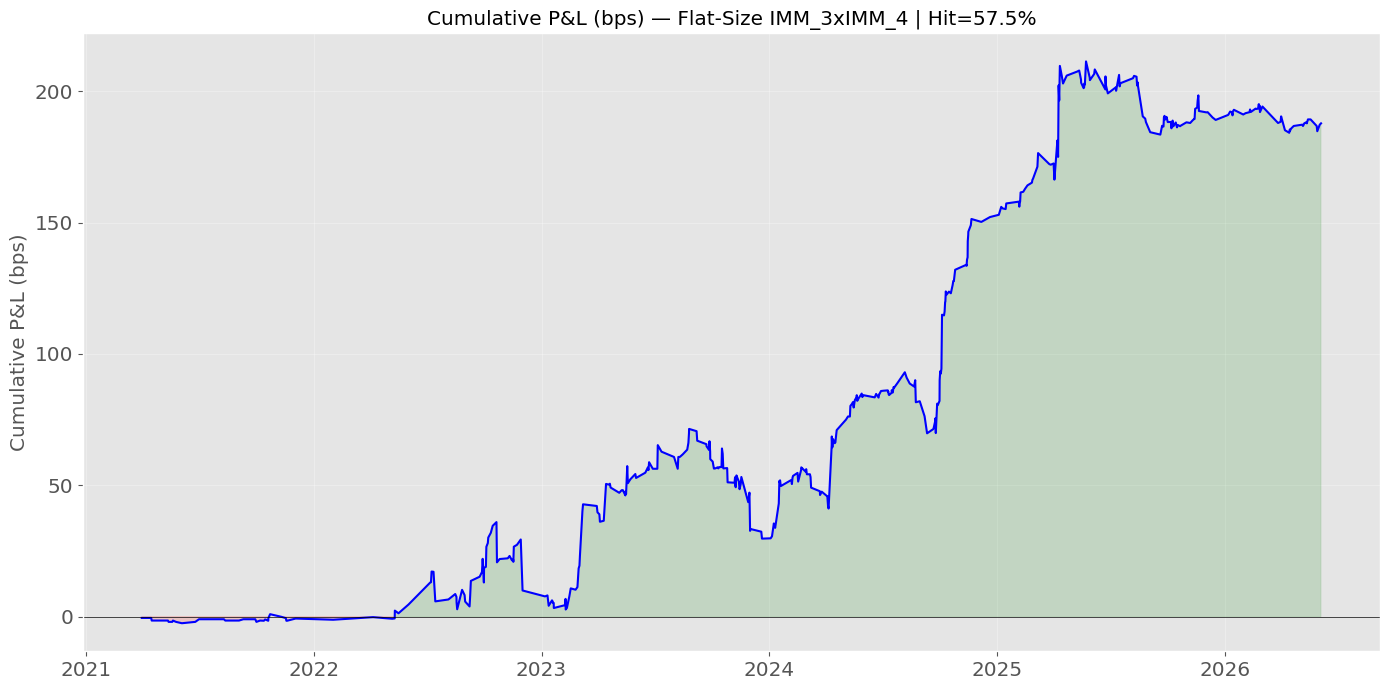

In [50]:
closed = pd.DataFrame(bt.portfolio.closed_positions_log)
assert not closed.empty, "No trades closed — check curve data"

closed["speaker"] = closed["source_query"].apply(lambda q: q.meta["speaker"])
closed["direction"] = closed["source_query"].apply(lambda q: q.meta["direction"])
closed["raw_score"] = closed["source_query"].apply(lambda q: q.meta["raw_score"])
closed["direction_label"] = closed["direction"].apply(lambda d: "hawk" if d == 1 else "dove")
closed["opened_at"] = pd.to_datetime(closed["opened_at"])
closed["closed_at"] = pd.to_datetime(closed["closed_at"])
closed["year"] = closed["opened_at"].dt.year

# P&L in basis points (flat sizing → divide by BASE_BPV)
closed["pnl_bps"] = closed["realized_pnl"] / BASE_BPV
closed["profitable"] = closed["pnl_bps"] > 0

n_trades = len(closed)
cum_bps = closed["pnl_bps"].sum()
avg_bps = closed["pnl_bps"].mean()
med_bps = closed["pnl_bps"].median()
std_bps = closed["pnl_bps"].std()
hit_rate = closed["profitable"].mean()
skew = closed["pnl_bps"].skew()
kurt = closed["pnl_bps"].kurtosis()

years = (closed["opened_at"].max() - closed["opened_at"].min()).days / 365.25
tpy = n_trades / years if years > 0 else n_trades
sharpe = (avg_bps / std_bps) * np.sqrt(tpy) if std_bps > 0 else 0.0

cum_series_bps = closed["pnl_bps"].cumsum()
max_dd_bps = (cum_series_bps - cum_series_bps.cummax()).min()

print("=" * 55)
print(f"  Naive Flat-Size Fed Hawk/Dove — {TENOR}")
print(f"  Entry: T-{ENTRY_OFFSET}, Exit: T+{EXIT_OFFSET}")
print("=" * 55)
print(f"  Trades:          {n_trades}")
print(f"  Cumulative:      {cum_bps:+.1f} bps")
print(f"  Avg P&L/trade:   {avg_bps:+.2f} bps")
print(f"  Median P&L:      {med_bps:+.2f} bps")
print(f"  Std P&L:         {std_bps:.2f} bps")
print(f"  Hit Rate:        {hit_rate:.1%}")
print(f"  Skew:            {skew:.2f}")
print(f"  Kurtosis:        {kurt:.2f}")
print(f"  Sharpe:          {sharpe:.2f}")
print(f"  Max Drawdown:    {max_dd_bps:.1f} bps")
print("=" * 55)

# --- Cumulative bps chart ---
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(closed["opened_at"].values, cum_series_bps.values, "b-", lw=1.5)
ax.fill_between(closed["opened_at"].values, 0, cum_series_bps.values,
                where=cum_series_bps.values >= 0, alpha=0.15, color="green")
ax.fill_between(closed["opened_at"].values, 0, cum_series_bps.values,
                where=cum_series_bps.values < 0, alpha=0.15, color="red")
ax.axhline(0, color="k", lw=0.5)
# ax.set_title(f"Cumulative P&L (bps) — Flat-Size {TENOR} | Sharpe={sharpe:.2f} | Hit={hit_rate:.1%}")
ax.set_title(f"Cumulative P&L (bps) — Flat-Size {TENOR} | Hit={hit_rate:.1%}")
ax.set_ylabel("Cumulative P&L (bps)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Per-Trade P&L Distribution (bps)

C:\Users\chris\AppData\Local\Temp\ipykernel_154960\2385981907.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([hawk_bps, dove_bps], labels=["Hawk", "Dove"], patch_artist=True,


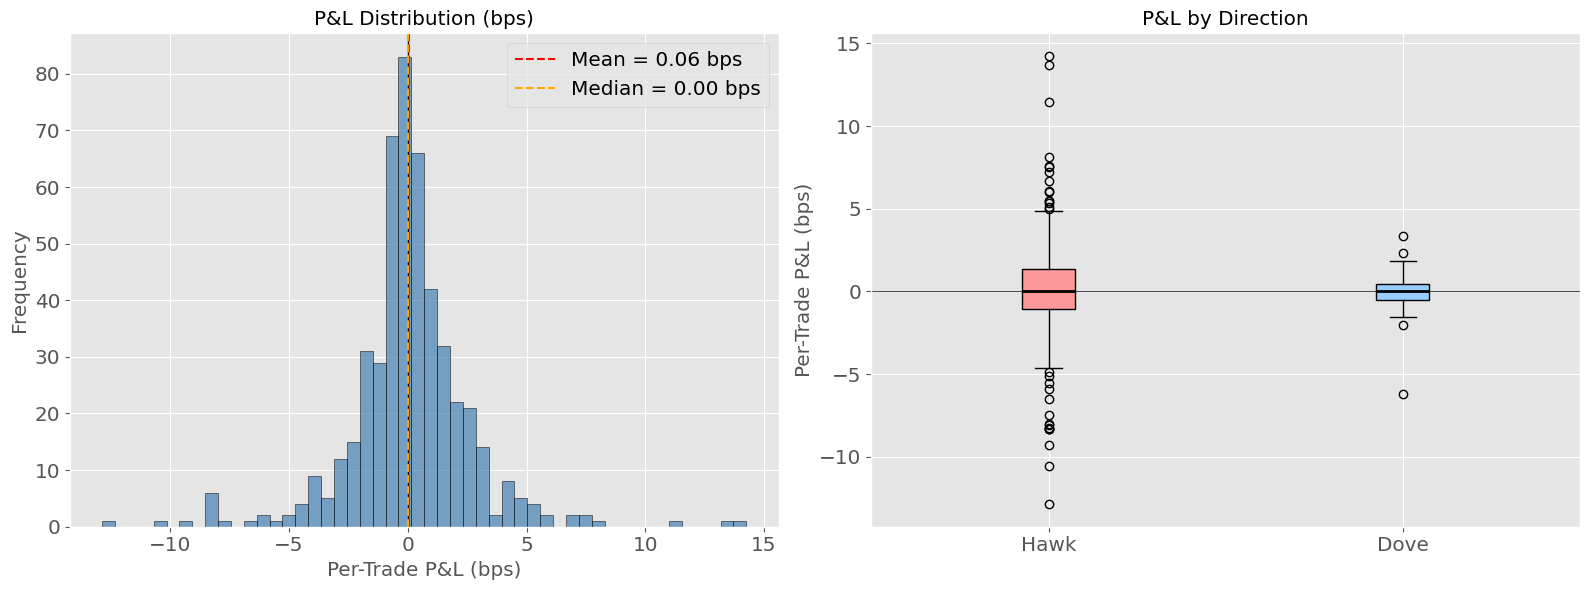

P&L Percentiles:


,Percentile,P&L (bps)
0,1%,-8.32
1,5%,-3.96
2,10%,-2.46
3,25%,-0.91
4,50%,0.00
5,75%,1.13
6,90%,2.52
7,95%,4.01
8,99%,7.54


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
ax = axes[0]
ax.hist(closed["pnl_bps"], bins=50, alpha=0.7, color="steelblue", edgecolor="black")
ax.axvline(0, color="k", lw=1)
ax.axvline(avg_bps, color="red", lw=1.5, ls="--", label=f"Mean = {avg_bps:.2f} bps")
ax.axvline(med_bps, color="orange", lw=1.5, ls="--", label=f"Median = {med_bps:.2f} bps")
ax.set_xlabel("Per-Trade P&L (bps)")
ax.set_ylabel("Frequency")
ax.set_title("P&L Distribution (bps)")
ax.legend()

# Box plot by direction
ax2 = axes[1]
hawk_bps = closed.loc[closed["direction"] == 1, "pnl_bps"]
dove_bps = closed.loc[closed["direction"] == -1, "pnl_bps"]
bp = ax2.boxplot([hawk_bps, dove_bps], labels=["Hawk", "Dove"], patch_artist=True,
                 medianprops={"color": "black", "lw": 2})
bp["boxes"][0].set_facecolor("#ff9999")
bp["boxes"][1].set_facecolor("#99ccff")
ax2.axhline(0, color="k", lw=0.5)
ax2.set_ylabel("Per-Trade P&L (bps)")
ax2.set_title("P&L by Direction")

plt.tight_layout()
plt.show()

# Percentile table
pcts = [1, 5, 10, 25, 50, 75, 90, 95, 99]
pct_vals = np.percentile(closed["pnl_bps"], pcts)
pct_df = pd.DataFrame({"Percentile": [f"{p}%" for p in pcts], "P&L (bps)": pct_vals})
print("P&L Percentiles:")
display(pct_df.style.format({"P&L (bps)": "{:.2f}"}))

## 6. Calendar-Year Breakdown

Calendar-Year Breakdown (bps):


,trades,total_bps,avg_bps,med_bps,std_bps,hit_rate,sharpe
year,,,,,,,
2021,43,+5.6,+0.13,+0.00,0.66,51.2%,1.31
2022,50,-4.4,-0.09,+0.29,3.89,54.0%,-0.16
2023,107,+1.2,+0.01,-0.22,3.09,44.9%,0.04
2024,136,+55.6,+0.41,+0.32,2.32,56.6%,2.05
2025,112,-13.4,-0.12,+0.00,2.70,50.0%,-0.47
2026,51,-13.9,-0.27,-0.00,1.13,47.1%,-1.73


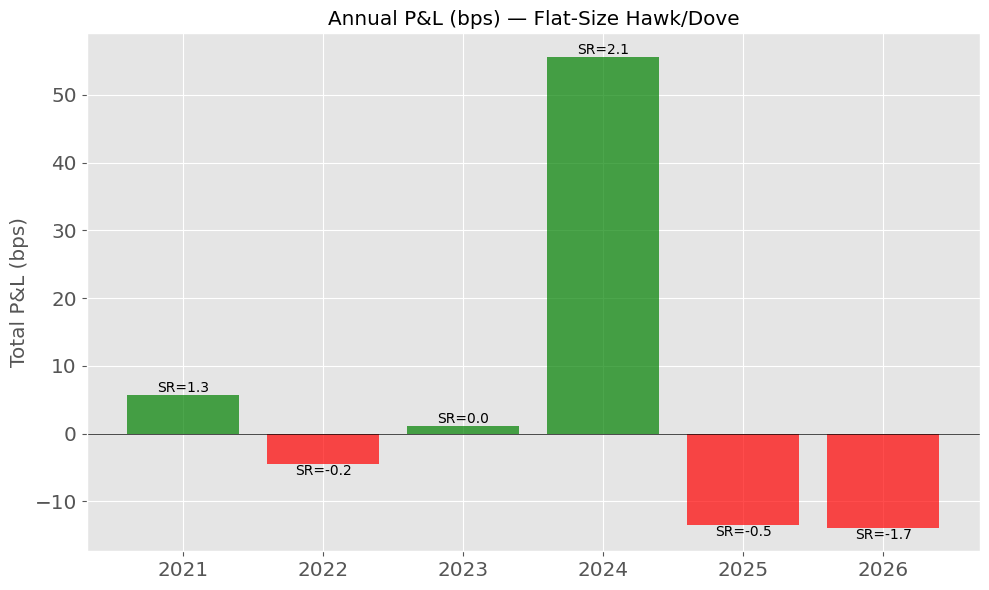

In [18]:
year_stats = (
    closed.groupby("year")
    .agg(
        trades=("pnl_bps", "count"),
        total_bps=("pnl_bps", "sum"),
        avg_bps=("pnl_bps", "mean"),
        med_bps=("pnl_bps", "median"),
        std_bps=("pnl_bps", "std"),
        hit_rate=("profitable", "mean"),
    )
)
year_stats["sharpe"] = (
    year_stats["avg_bps"] / year_stats["std_bps"]
) * np.sqrt(year_stats["trades"])

print("Calendar-Year Breakdown (bps):")
display(year_stats.style.format({
    "total_bps": "{:+.1f}", "avg_bps": "{:+.2f}", "med_bps": "{:+.2f}",
    "std_bps": "{:.2f}", "hit_rate": "{:.1%}", "sharpe": "{:.2f}",
}))

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["green" if x > 0 else "red" for x in year_stats["total_bps"]]
ax.bar(year_stats.index.astype(str), year_stats["total_bps"], color=colors, alpha=0.7)
ax.set_ylabel("Total P&L (bps)")
ax.set_title("Annual P&L (bps) — Flat-Size Hawk/Dove")
ax.axhline(0, color="k", lw=0.5)
for i, (yr, row) in enumerate(year_stats.iterrows()):
    ax.text(i, row["total_bps"], f"SR={row['sharpe']:.1f}", ha="center",
            va="bottom" if row["total_bps"] >= 0 else "top", fontsize=10)
plt.tight_layout()
plt.show()

## 7. Hawk vs Dove

Hawk vs Dove (bps):


,trades,total_bps,avg_bps,med_bps,std_bps,hit_rate
direction_label,,,,,,
hawk,419,+30.5,+0.07,+0.01,2.82,51.1%
dove,80,+0.2,+0.00,+0.00,1.06,50.0%


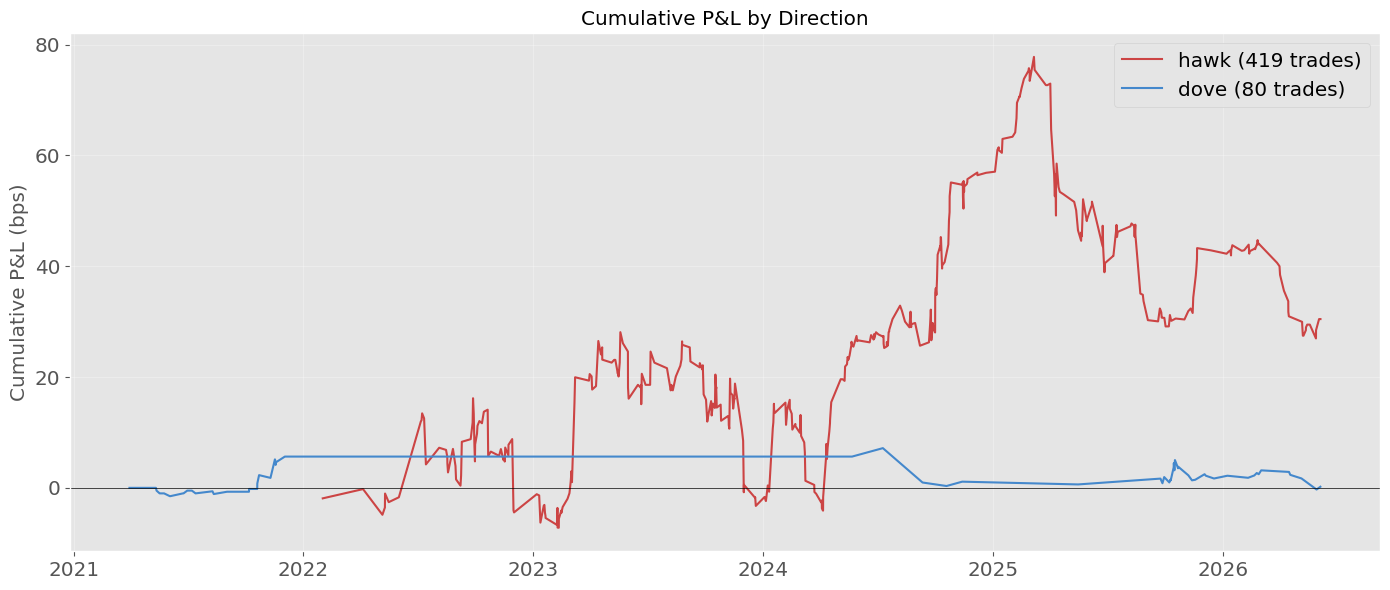

In [19]:
dir_stats = (
    closed.groupby("direction_label")
    .agg(
        trades=("pnl_bps", "count"),
        total_bps=("pnl_bps", "sum"),
        avg_bps=("pnl_bps", "mean"),
        med_bps=("pnl_bps", "median"),
        std_bps=("pnl_bps", "std"),
        hit_rate=("profitable", "mean"),
    )
    .sort_values("total_bps", ascending=False)
)

print("Hawk vs Dove (bps):")
display(dir_stats.style.format({
    "total_bps": "{:+.1f}", "avg_bps": "{:+.2f}", "med_bps": "{:+.2f}",
    "std_bps": "{:.2f}", "hit_rate": "{:.1%}",
}))

# Cumulative bps by direction
fig, ax = plt.subplots(figsize=(14, 6))
for label, color in [("hawk", "#cc4444"), ("dove", "#4488cc")]:
    mask = closed["direction_label"] == label
    sub = closed[mask].sort_values("opened_at")
    ax.plot(sub["opened_at"].values, sub["pnl_bps"].cumsum().values,
            lw=1.5, color=color, label=f"{label} ({mask.sum()} trades)")
ax.axhline(0, color="k", lw=0.5)
ax.set_ylabel("Cumulative P&L (bps)")
ax.set_title("Cumulative P&L by Direction")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Speaker Attribution

,trades,total_bps,avg_bps,hit_rate,avg_score
speaker,,,,,
Williams,42,+21.3,+0.51,64.3%,24.5
Waller,41,+17.6,+0.43,51.2%,3.2
Bostic,64,+14.5,+0.23,56.2%,-7.8
Powell,34,+14.4,+0.42,50.0%,29.9
Musalem,22,+11.3,+0.51,54.5%,18.7
Bowman,63,+7.3,+0.12,50.8%,11.0
Collins,7,+5.2,+0.75,57.1%,13.6
Kashkari,10,+4.9,+0.49,70.0%,20.2
Jefferson,3,+4.0,+1.32,100.0%,17.7


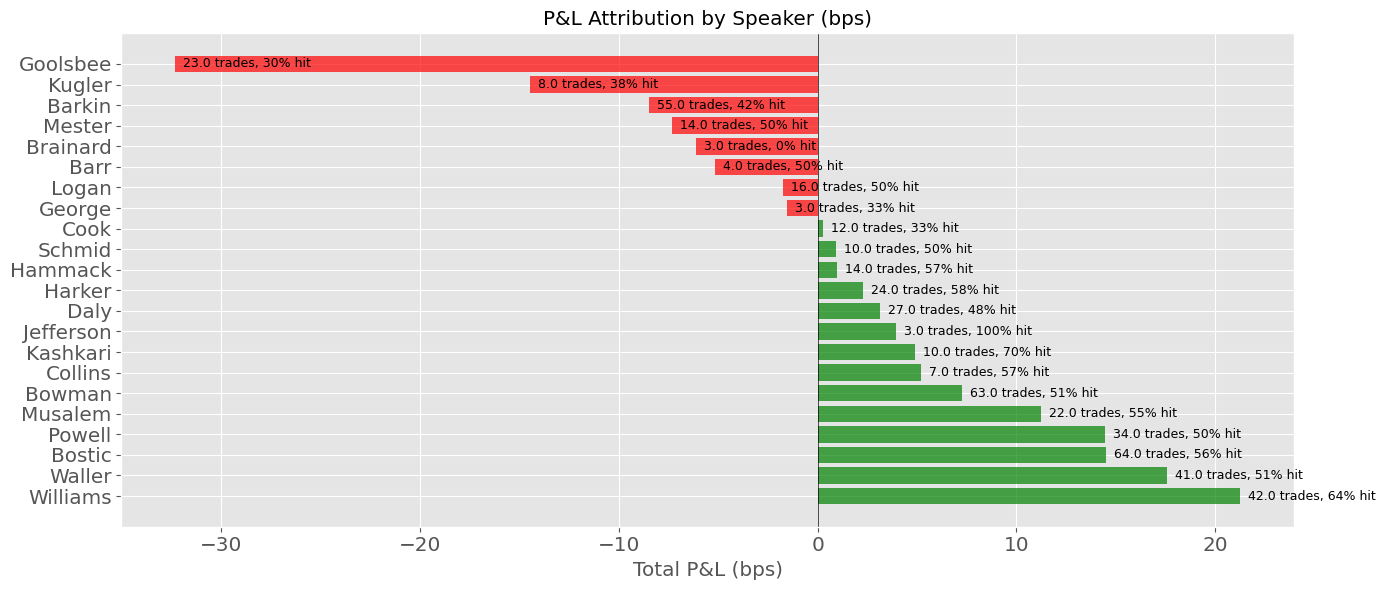

In [20]:
speaker_stats = (
    closed.groupby("speaker")
    .agg(
        trades=("pnl_bps", "count"),
        total_bps=("pnl_bps", "sum"),
        avg_bps=("pnl_bps", "mean"),
        hit_rate=("profitable", "mean"),
        avg_score=("raw_score", "mean"),
    )
    .sort_values("total_bps", ascending=False)
)
display(speaker_stats.style.format({
    "total_bps": "{:+.1f}", "avg_bps": "{:+.2f}",
    "hit_rate": "{:.1%}", "avg_score": "{:.1f}",
}))

fig, ax = plt.subplots(figsize=(14, 6))
colors = ["green" if x > 0 else "red" for x in speaker_stats["total_bps"]]
ax.barh(speaker_stats.index, speaker_stats["total_bps"], color=colors, alpha=0.7)
ax.set_xlabel("Total P&L (bps)")
ax.set_title("P&L Attribution by Speaker (bps)")
ax.axvline(0, color="k", lw=0.5)
for i, (speaker, row) in enumerate(speaker_stats.iterrows()):
    ax.text(row["total_bps"], i,
            f"  {row['trades']} trades, {row['hit_rate']:.0%} hit",
            va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 9. Trade Log

In [21]:
trade_log = closed[[
    "opened_at", "closed_at", "speaker", "direction_label",
    "raw_score", "pnl_bps", "profitable",
]].copy()
trade_log["cum_bps"] = trade_log["pnl_bps"].cumsum()
trade_log = trade_log.sort_values("opened_at").reset_index(drop=True)

display(trade_log.style.format({
    "raw_score": "{:.1f}",
    "pnl_bps": "{:+.2f}",
    "cum_bps": "{:+.1f}",
}).bar(subset=["pnl_bps"], color=["#d65f5f", "#5fba7d"], align="zero"))

,opened_at,closed_at,speaker,direction_label,raw_score,pnl_bps,profitable,cum_bps
0,2021-03-30 11:45:00-04:00,2021-03-30 14:00:00-04:00,Bostic,dove,-22.0,-0.00,False,-0.0
1,2021-04-02 10:45:00-04:00,2021-04-02 13:00:00-04:00,Bostic,dove,-22.0,-0.00,False,-0.0
2,2021-04-13 15:00:00-04:00,2021-04-13 16:59:00-04:00,Bostic,dove,-22.0,+0.00,True,+0.0
3,2021-04-14 15:45:00-04:00,2021-04-14 16:59:00-04:00,Bostic,dove,-22.0,+0.00,True,+0.0
4,2021-04-15 11:15:00-04:00,2021-04-15 13:30:00-04:00,Bostic,dove,-22.0,-0.00,False,-0.0
5,2021-05-06 12:45:00-04:00,2021-05-06 15:00:00-04:00,Bostic,dove,-22.0,+0.00,True,-0.0
6,2021-05-11 13:00:00-04:00,2021-05-11 15:15:00-04:00,Bostic,dove,-24.0,+0.00,True,-0.0
7,2021-05-12 12:45:00-04:00,2021-05-12 15:00:00-04:00,Bostic,dove,-24.0,-0.50,False,-0.5
8,2021-05-17 10:10:00-04:00,2021-05-17 12:25:00-04:00,Bostic,dove,-24.0,-0.50,False,-1.0
9,2021-05-18 12:15:00-04:00,2021-05-18 14:30:00-04:00,Bostic,dove,-24.0,+0.00,True,-1.0
